# 收入波动问题 I：离散化与 VFI

```{include} _admonition/gpu.md
```

## 概述


在本讲中，我们研究一个无限存活消费者的最优储蓄问题——即 {cite}`Ljungqvist2012` 第 1.3 节中描述的"共同祖先"。

这个储蓄问题通常被称为**收入波动问题**或**家庭问题**。

它是许多代表性宏观经济模型的一个基本子问题

* {cite}`Aiyagari1994`
* {cite}`Huggett1993`
* 等等

它与 {doc}`os_stochastic` 中的决策问题相关，但在一些重要方面有所不同。

例如，

1. 该主体的选择问题包含一个可加性收入项，这会导致一个偶尔起约束作用的约束。
2. 影响预算约束的冲击是相关的，这迫使我们跟踪一个额外的状态变量。

我们将从一个相对基础的模型版本开始，通过传统的离散化 + 值函数迭代来求解它。

尽管这种方法并不是最快或最高效的，但它非常稳健和灵活。

例如，如果我们突然决定加入 [Epstein--Zin 偏好](https://en.wikipedia.org/wiki/Epstein%E2%80%93Zin_preferences)，或者将普通的条件期望修改为分位数，该技术仍然能够很好地工作。

```{note}
对于我们将使用的其他一些方法（例如内生网格法），情况就并非如此。

这是计算与分析中的一条普遍规律——虽然我们通常可以通过利用结构来设计更快的算法，但这些新算法通常不那么稳健。

它们之所以不那么稳健，恰恰是因为它们利用了更多的结构——这意味着它们不可避免地更容易受到变化的影响。
```

除了 Anaconda 之外，本讲还需要以下库：

In [1]:
!pip install quantecon jax

我们将使用以下导入：

In [2]:
import quantecon as qe
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']
from typing import NamedTuple
from time import time

我们将使用 64 位浮点数以获得额外的精度。

In [3]:
jax.config.update("jax_enable_x64", True)

## 设置

我们研究一个家庭，它选择一个状态相依的消费计划 $\{c_t\}_{t \geq 0}$ 以最大化

$$
\mathbb{E} \, \sum_{t=0}^{\infty} \beta^t u(c_t)
$$

约束条件为

$$
    a_{t+1} + c_t \leq R a_t + y_t
$$

其中

* $c_t$ 是消费且 $c_t \geq 0$，
* $a_t$ 是资产且 $a_t \geq 0$，
* $R = 1 + r$ 是总回报率，
* $(y_t)_{t \geq 0}$ 是劳动收入，取值于某个有限集 $\mathsf Y$。

我们在下面假设劳动收入动态遵循一个离散化的 AR(1)过程。

我们设 $\mathsf S := \mathbb{R}_+ \times \mathsf Y$，它表示状态空间。

**值函数** $V \colon \mathsf S \to \mathbb{R}$ 定义为

```{math}
:label: eqvfs

V(a, y) := \max \, \mathbb{E}
\left\{
\sum_{t=0}^{\infty} \beta^t u(c_t)
\right\}
```

其中最大化是在给定 $(a_0, y_0) = (a, y)$ 时所有可行的消费序列上进行的。

贝尔曼方程为

$$   
    v(a, y) = \max_{0 \leq a' \leq Ra + y}
    \left\{
        u(Ra + y - a') + β \sum_{y'} v(a', y') Q(y, y') 
    \right\}
$$

其中

$$
    u(c) = \frac{c^{1-\gamma}}{1-\gamma} 
$$

在代码中我们使用函数

$$   
    B((a, y), a', v) = u(Ra + y - a') + β \sum_{y'} v(a', y') Q(y, y'). 
$$

来封装贝尔曼方程的右侧。



## 代码

以下代码定义了一个 `NamedTuple` 来存储模型参数和网格。

(prgm:create-consumption-model)=

In [4]:
class Model(NamedTuple):
    β: float              # 贴现因子
    R: float              # 总利率
    γ: float              # CRRA 参数
    a_grid: jnp.ndarray   # 资产网格
    y_grid: jnp.ndarray   # 收入网格
    Q: jnp.ndarray        # 收入的马尔可夫矩阵


def create_consumption_model(
        R=1.01,                    # 总利率
        β=0.98,                    # 贴现因子
        γ=2,                       # CRRA 参数
        a_min=0.01,                # 最小资产
        a_max=10.0,                # 最大资产
        a_size=150,                # 网格大小
        ρ=0.9, ν=0.1, y_size=100   # 收入参数
    ):
    """
    创建消费-储蓄模型的一个实例。

    """
    a_grid = jnp.linspace(a_min, a_max, a_size)
    mc = qe.tauchen(n=y_size, rho=ρ, sigma=ν)
    y_grid, Q = jnp.exp(mc.state_values), jax.device_put(mc.P)
    return Model(β, R, γ, a_grid, y_grid, Q)

现在我们定义贝尔曼方程的右侧。

我们将使用一种类似于 Matlab 和 NumPy 的向量化编码风格（避免所有循环）。

我们邀请你在练习中探索一种基于 `jax.vmap` 的替代风格。

In [5]:
@jax.jit
def B(v, model):
    """
    贝尔曼方程右侧（最大化之前）的向量化版本，它是一个表示

        B(a, y, a′) = u(Ra + y - a′) + β Σ_y′ v(a′, y′) Q(y, y′)

    的 3D 数组，涵盖所有 (a, y, a′)。
    """

    # 解包
    β, R, γ, a_grid, y_grid, Q = model
    a_size, y_size = len(a_grid), len(y_grid)

    # 将当前奖励 r(a, y, ap) 计算为数组 r[i, j, ip]
    a  = jnp.reshape(a_grid, (a_size, 1, 1))    # a[i]   ->  a[i, j, ip]
    y  = jnp.reshape(y_grid, (1, y_size, 1))    # z[j]   ->  z[i, j, ip]
    ap = jnp.reshape(a_grid, (1, 1, a_size))    # ap[ip] -> ap[i, j, ip]
    c = R * a + y - ap

    # 计算所有 (a, y, ap) 组合下的延续奖励
    v = jnp.reshape(v, (1, 1, a_size, y_size))  # v[ip, jp] -> v[i, j, ip, jp]
    Q = jnp.reshape(Q, (1, y_size, 1, y_size))  # Q[j, jp]  -> Q[i, j, ip, jp]
    EV = jnp.sum(v * Q, axis=3)                 # 对最后一个索引 jp 求和

    # 计算贝尔曼方程的右侧
    return jnp.where(c > 0, c**(1-γ)/(1-γ) + β * EV, -jnp.inf)

一些读者可能会担心我们正在创建高维数组，从而导致效率低下。

能否通过更仔细的向量化来避免它们？

事实上这并不必要：这个函数将由 JAX 进行 JIT 编译，而 JIT 编译器将优化编译后的代码以最小化内存使用。

贝尔曼算子 $T$ 可以通过以下方式实现

In [6]:
@jax.jit
def T(v, model):
    "贝尔曼算子。"
    return jnp.max(B(v, model), axis=2)

下一个函数在给定 $v$ 的情况下计算一个 $v$-贪婪策略（即最大化贝尔曼方程右侧的策略）。

In [7]:
@jax.jit
def get_greedy(v, model):
    "计算 v-贪婪策略，以一组索引的形式返回。"
    return jnp.argmax(B(v, model), axis=2)

### 值函数迭代

现在我们定义一个实现 VFI 的求解器。

首先，我们使用标准的 Python 循环编写一个简单的版本。

In [8]:
def value_function_iteration_python(model, tol=1e-5, max_iter=10_000):
    """
    使用 Python 循环通过逐次近似实现 VFI。
    """
    v = jnp.zeros((len(model.a_grid), len(model.y_grid)))
    error = tol + 1
    k = 0

    while error > tol and k < max_iter:
        v_new = T(v, model)
        error = jnp.max(jnp.abs(v_new - v))
        v = v_new
        k += 1

    return v, get_greedy(v, model)

接下来我们编写一个使用 `jax.lax.while_loop` 的版本。

In [9]:
@jax.jit
def value_function_iteration(model, tol=1e-5, max_iter=10_000):
    """
    使用逐次近似实现 VFI。
    """
    def body_fun(k_v_err):
        k, v, error = k_v_err
        v_new = T(v, model)
        error = jnp.max(jnp.abs(v_new - v))
        return k + 1, v_new, error

    def cond_fun(k_v_err):
        k, v, error = k_v_err
        return jnp.logical_and(error > tol, k < max_iter)

    v_init = jnp.zeros((len(model.a_grid), len(model.y_grid)))
    k, v_star, error = jax.lax.while_loop(cond_fun, body_fun,
                                          (1, v_init, tol + 1))
    return v_star, get_greedy(v_star, model)

### 计时

让我们创建一个实例并比较两种实现。

In [10]:
model = create_consumption_model()

首先让我们对 Python 版本计时。

In [11]:
print("Starting VFI using Python loop.")
start = time()
v_star_python, σ_star_python = value_function_iteration_python(model)
python_time = time() - start
print(f"VFI completed in {python_time} seconds.")

Starting VFI using Python loop.
VFI completed in 9.656916618347168 seconds.


VFI completed in 9.656916618347168 seconds.


现在让我们对 `jax.lax.while_loop` 版本计时。

In [12]:
print("Starting VFI using jax.lax.while_loop.")
start = time()
v_star_jax, σ_star_jax = value_function_iteration(model)
v_star_jax.block_until_ready()
jax_with_compile = time() - start
print(f"VFI completed in {jax_with_compile} seconds.")

Starting VFI using jax.lax.while_loop.
VFI completed in 1.4713940620422363 seconds.


VFI completed in 1.4713940620422363 seconds.


让我们再次运行它以消除编译时间。

In [13]:
start = time()
v_star_jax, σ_star_jax = value_function_iteration(model)
v_star_jax.block_until_ready()
jax_without_compile = time() - start
print(f"VFI completed in {jax_without_compile} seconds.")

VFI completed in 1.3514881134033203 seconds.


让我们检查这两种实现是否产生相同的结果。

In [14]:
print(f"Values match: {jnp.allclose(v_star_python, v_star_jax)}")
print(f"Policies match: {jnp.allclose(σ_star_python, σ_star_jax)}")

Values match: True
Policies match: True


这是使用 `jax.lax.while_loop` 带来的加速。

In [15]:
print(f"Relative speed = {python_time / jax_without_compile:.2f}")

Relative speed = 7.15


### 资产动态

为了理解长期行为，让我们考察最优策略下的资产积累动态。

以下 45 度图展示了资产如何随时间演变：

findfont: Failed to find font weight normal, now using 600.


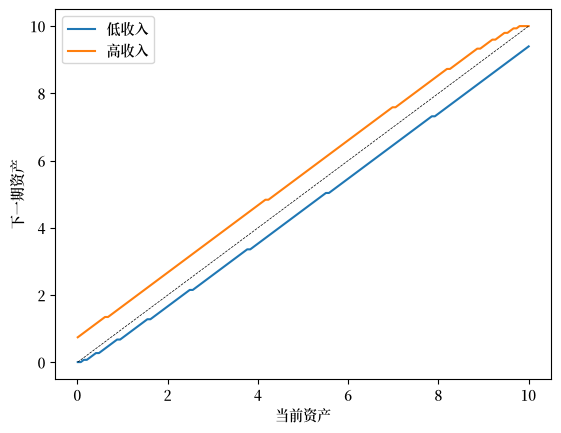

In [16]:
fig, ax = plt.subplots()

# 绘制第一个和最后一个收入状态的资产积累
for j, label in zip([0, -1], ['低收入', '高收入']):
    # 获取每个当前资产水平的下一期资产
    a_next = model.a_grid[σ_star_jax[:, j]]
    ax.plot(model.a_grid, a_next, label=label)

# 添加 45 度线
ax.plot(model.a_grid, model.a_grid, 'k--', linewidth=0.5)
ax.set(xlabel='当前资产', ylabel='下一期资产')
ax.legend()
plt.show()

该图展示了每个收入状态的资产积累规则。

虚线是 45 度线，表示 $a_{t+1} = a_t$ 的点。

我们看到：

* 对于低收入水平，资产往往会减少（位于 45 度线下方的点）
* 对于高收入水平，在低资产水平时资产往往会增加
* 该动态表明会收敛到一个平稳分布


## 练习

```{exercise}
:label: ifp_ex1

在本练习中，我们探索一种使用 `jax.vmap` 实现值函数迭代的替代方法。

对于这个简单的最优储蓄问题，直接向量化相对容易。

特别地，将贝尔曼方程的右侧表示为一个数组是很直接的，该数组存储了在每个状态和控制下对该函数的求值。

然而，对于更复杂的模型，直接向量化可能要困难得多。

出于这个原因，掌握另一种实现快速 JAX 实现的方法会很有帮助。

你的任务是实现一个版本，它：

1. 将贝尔曼算子的右侧写成关于单个状态和控制的函数，以及
2. 在外部应用 `jax.vmap` 以实现并行化求解。

具体来说：

1. 重写 `B`，使其接受对应于 `(a, y, a′)` 的索引 `(i, j, ip)`，并计算这些特定索引的贝尔曼方程。
2. 依次使用 `jax.vmap` 对所有索引进行向量化（使用前面示例中展示的分阶段 vmap）。
3. 使用向量化的 `B` 实现 `T_vmap` 和 `get_greedy_vmap` 函数。
4. 使用 `jax.lax.while_loop` 实现 `value_iteration_vmap`。
5. 测试你的实现是否产生与直接向量化方法相同的结果。
6. 比较两种方法的执行时间。
```

```{solution-start} ifp_ex1
:class: dropdown
```

这是一个解决方案。

首先让我们重写 `B` 使其与单个索引一起工作：

In [17]:
def B(v, model, i, j, ip):
    """
    最大化之前贝尔曼方程的右侧，其形式为

        B(a, y, a′) = u(Ra + y - a′) + β Σ_y′ v(a′, y′) Q(y, y′)

    索引为 (i, j, ip) -> (a, y, a′)。
    """
    β, R, γ, a_grid, y_grid, Q = model
    a, y, ap  = a_grid[i], y_grid[j], a_grid[ip]
    c = R * a + y - ap
    EV = jnp.sum(v[ip, :] * Q[j, :])
    return jnp.where(c > 0, c**(1-γ)/(1-γ) + β * EV, -jnp.inf)

现在我们依次应用 `vmap` 来模拟嵌套循环。

In [18]:
B_1    = jax.vmap(B,   in_axes=(None, None, None, None, 0))
B_2    = jax.vmap(B_1, in_axes=(None, None, None, 0,    None))
B_vmap = jax.vmap(B_2, in_axes=(None, None, 0,    None, None))

这是 `vmap` 情况下的贝尔曼算子和 `get_greedy` 函数。

In [19]:
@jax.jit
def T_vmap(v, model):
    "贝尔曼算子。"
    a_indices = jnp.arange(len(model.a_grid))
    y_indices = jnp.arange(len(model.y_grid))
    B_values = B_vmap(v, model, a_indices, y_indices, a_indices)
    return jnp.max(B_values, axis=-1)

@jax.jit
def get_greedy_vmap(v, model):
    "计算 v-贪婪策略，以一组索引的形式返回。"
    a_indices = jnp.arange(len(model.a_grid))
    y_indices = jnp.arange(len(model.y_grid))
    B_values = B_vmap(v, model, a_indices, y_indices, a_indices)
    return jnp.argmax(B_values, axis=-1)

这是迭代例程。

In [20]:
def value_iteration_vmap(model, tol=1e-5, max_iter=10_000):
    """
    使用 vmap 和逐次近似实现 VFI。
    """
    def body_fun(k_v_err):
        k, v, error = k_v_err
        v_new = T_vmap(v, model)
        error = jnp.max(jnp.abs(v_new - v))
        return k + 1, v_new, error

    def cond_fun(k_v_err):
        k, v, error = k_v_err
        return jnp.logical_and(error > tol, k < max_iter)

    v_init = jnp.zeros((len(model.a_grid), len(model.y_grid)))
    k, v_star, error = jax.lax.while_loop(cond_fun, body_fun,
                                          (1, v_init, tol + 1))
    return v_star, get_greedy_vmap(v_star, model)

让我们看看使用 `vmap` 方法求解模型需要多长时间。

In [21]:
print("Starting VFI using vmap.")
start = time()
v_star_vmap, σ_star_vmap = value_iteration_vmap(model)
v_star_vmap.block_until_ready()
jax_vmap_with_compile = time() - start
print(f"VFI completed in {jax_vmap_with_compile} seconds.")

Starting VFI using vmap.
VFI completed in 1.239804983139038 seconds.


VFI completed in 1.239804983139038 seconds.


让我们再次运行它以消除编译时间。

In [22]:
start = time()
v_star_vmap, σ_star_vmap = value_iteration_vmap(model)
v_star_vmap.block_until_ready()
jax_vmap_without_compile = time() - start
print(f"VFI completed in {jax_vmap_without_compile} seconds.")

VFI completed in 1.1454787254333496 seconds.


我们需要确保得到相同的结果。

In [23]:
print(jnp.allclose(v_star_vmap, v_star_jax))
print(jnp.allclose(σ_star_vmap, σ_star_jax))

True
True


这是与第一个 JAX 实现（使用直接向量化）的比较。

In [24]:
print(f"Relative speed = {jax_without_compile / jax_vmap_without_compile}")

Relative speed = 1.1798456692349608


两个 JAX 版本的执行时间相对相近。

然而，正如上面所强调的，掌握第二种方法（即 `vmap` 方法）在面对具有更复杂贝尔曼方程的动态规划问题时会很有帮助。

```{solution-end}
```